In [1]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from wordcloud import WordCloud

plt.style.use('ggplot')

In [3]:
# Step 3: Load Dataset
df = pd.read_csv('netflix_titles.csv')


In [4]:
# Display first 5 rows
print(df.head())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
# Step 4: Explore Dataset
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000
show_id            0
type               0
title              0
dire

# **Dashboard** 1: Movies vs TV Shows


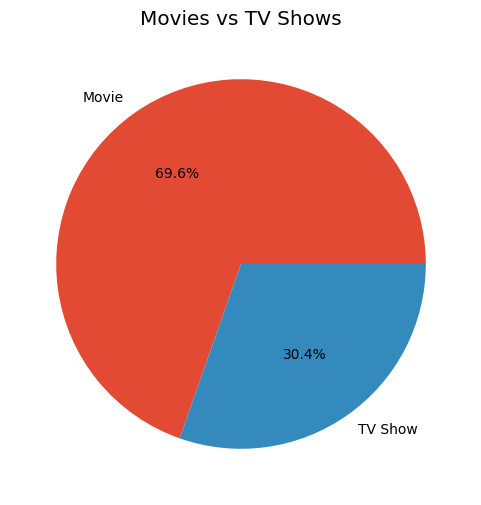

In [6]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)

plt.title("Movies vs TV Shows")
plt.show()


# Dashboard 2: Content Growth


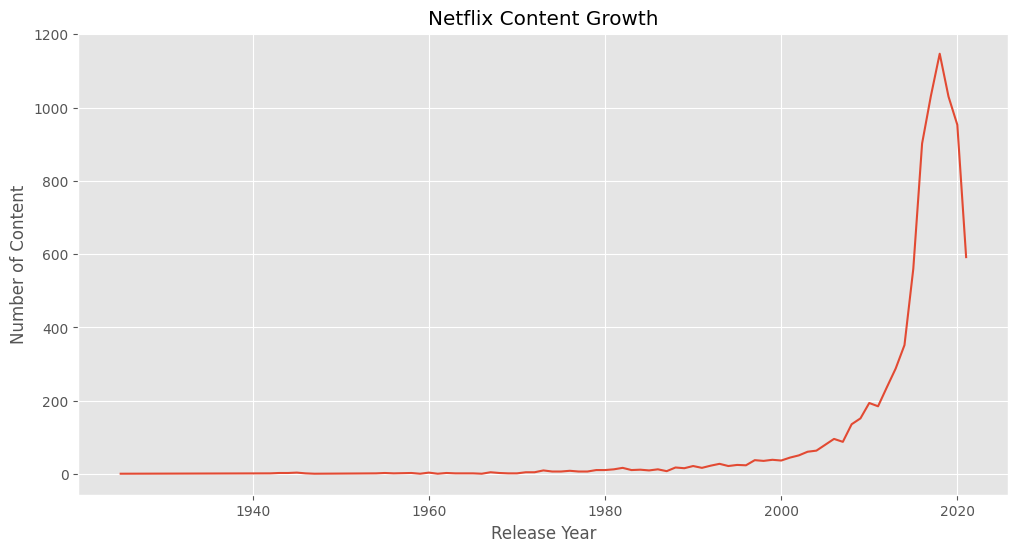

In [7]:
year_counts = df['release_year'] \
    .value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(
    year_counts.index,
    year_counts.values
)

plt.title("Netflix Content Growth")
plt.xlabel("Release Year")
plt.ylabel("Number of Content")
plt.show()



# Dashboard 3: Top Countries


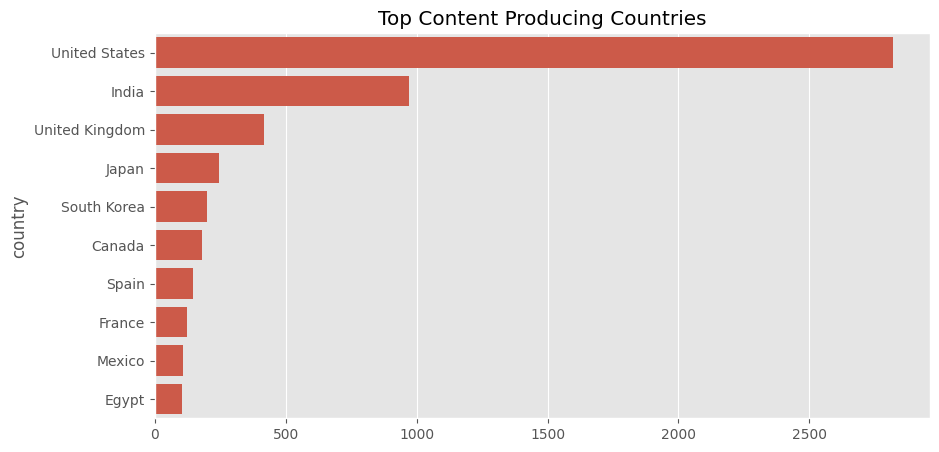

In [8]:
country_count = df['country'] \
    .value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title("Top Content Producing Countries")
plt.show()


# Dashboard 4: Ratings Distribution


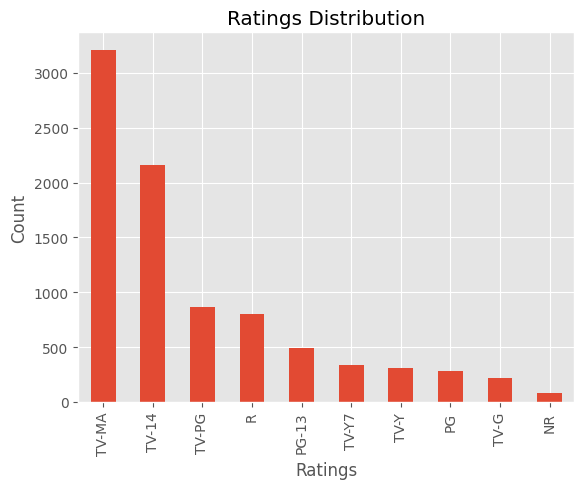

In [9]:
df['rating'] \
.value_counts() \
.head(10) \
.plot(kind='bar')

plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()


# Dashboard 5: Genre Analysis


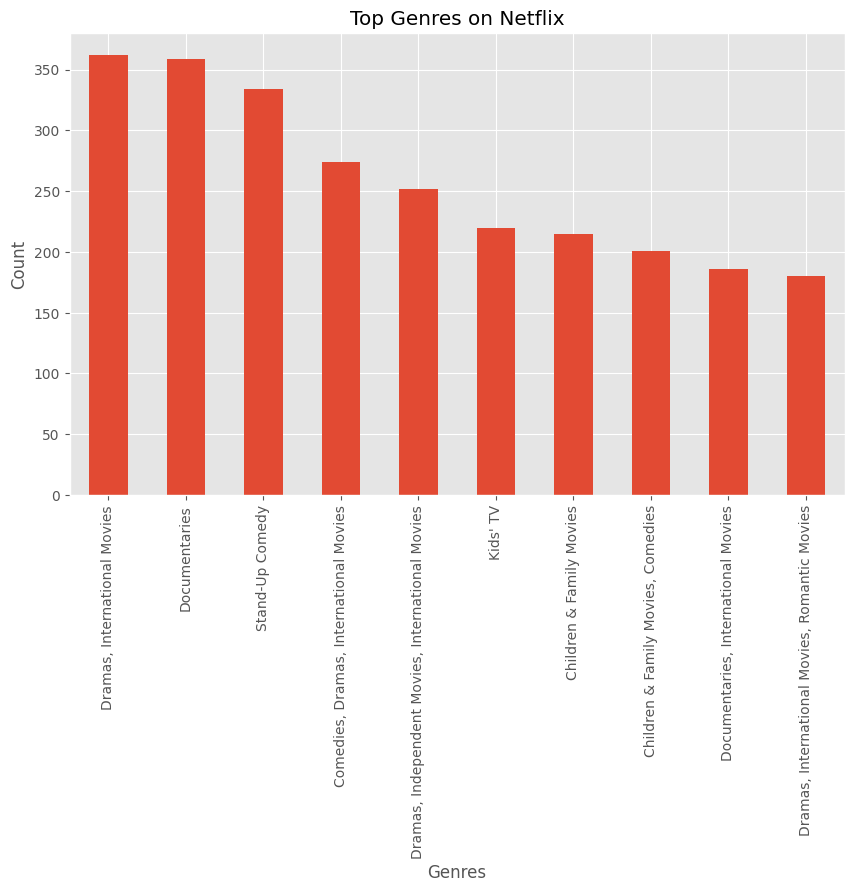

In [10]:
genre_count = df['listed_in'] \
    .value_counts().head(10)

plt.figure(figsize=(10,6))

genre_count.plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.show()



# Dashboard 6: Interactive Plotly


In [11]:
fig = px.histogram(
    df,
    x="release_year",
    color="type",
    title="Content by Year & Type",
    barmode="overlay"
)

fig.show()



# Dashboard 7: Word Cloud


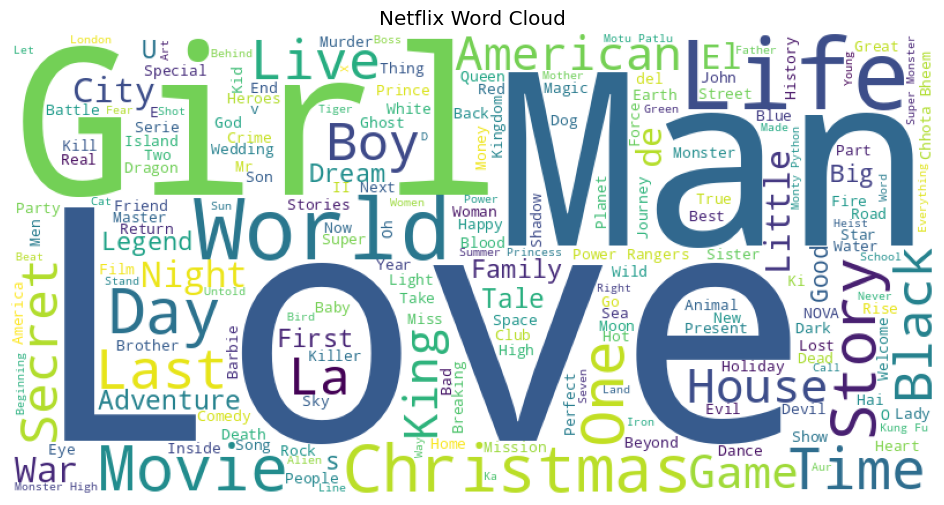

In [12]:
text = " ".join(df['title'].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)

plt.axis("off")
plt.title("Netflix Word Cloud")
plt.show()


# Advanced Task: Top Directors


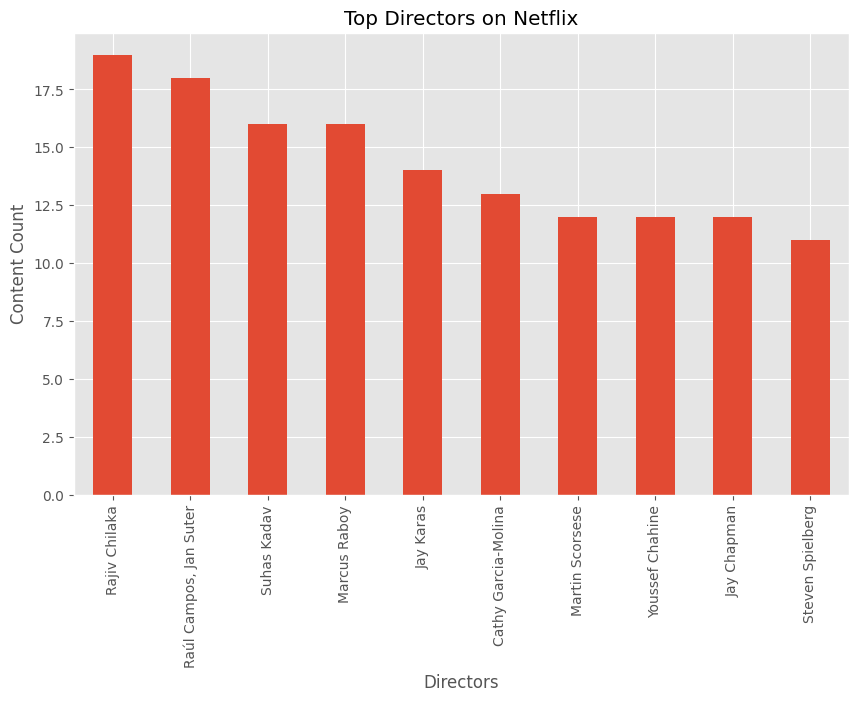

In [13]:
top_directors = df['director'] \
    .value_counts() \
    .head(10)

plt.figure(figsize=(10,6))

top_directors.plot(kind='bar')

plt.title("Top Directors on Netflix")
plt.xlabel("Directors")
plt.ylabel("Content Count")
plt.show()